In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

entity = "18920011663-king-s-college-london"
project = "World_Model_Curriculum_Learning"          
prefixes = ["CL_WM_without_editing", "CL_WM_without_RB", "CL_WM*"]           
# Define the keys for the data you want to extract
step_key = "curriculum_step"
metric_name = "final_task_performance"
api = wandb.Api(timeout=60)
runs = api.runs(f"{entity}/{project}")
step_min, step_max = 0, 50  # Step range to display

In [ ]:
def load_group(prefix):
    runs = api.runs(f"{entity}/{project}")
    selected_runs = [run for run in runs if run.name.startswith(prefix)]
    print(f"\nGroup '{prefix}': Found {len(selected_runs)} runs")

    data_frames = []
    for run in selected_runs:
        try:
            history = run.history()
            if metric_name not in history.columns or step_key not in history.columns:
                print(f"Skipping {run.name}: missing '{metric_name}' or '{step_key}'")
                continue
            df = history[[step_key, metric_name]].dropna()
            df = df.groupby(step_key).mean().reset_index()
            df.rename(columns={metric_name: run.name}, inplace=True)
            data_frames.append(df.set_index(step_key))
            print(f"  Loaded {run.name}")
        except Exception as e:
            print(f"  Error loading {run.name}: {e}")

    if not data_frames:
        return None, None, None
    
    merged_df = pd.concat(data_frames, axis=1)
    mean = merged_df.mean(axis=1)
    std = merged_df.std(axis=1)

    return merged_df.index, mean, std

plt.figure(figsize=(12, 6))

for prefix in prefixes:
    steps, mean, std = load_group(prefix)
    if steps is None:
        continue
    
    # Filter to only include step range 0 to 50
    step_mask = (steps >= step_min) & (steps <= step_max)
    steps_filtered = steps[step_mask]
    mean_filtered = mean[step_mask]
    std_filtered = std[step_mask]
    
    plt.plot(steps_filtered, mean_filtered, linewidth=2, label=f"{prefix} ")
    plt.fill_between(steps_filtered, mean_filtered - std_filtered, mean_filtered + std_filtered, alpha=0.2)

plt.xlabel(step_key)
plt.ylabel(metric_name)
plt.title(f"Comparison of Run Groups")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load CSV
csv_path = "logs/target_eval_log.csv"  # Adjust if necessary
df = pd.read_csv(csv_path)

# Create a continuous index for x-axis
df['global_index'] = range(1, len(df) + 1)

# Create plot
plt.figure(figsize=(14, 6))
plt.plot(df['global_index'], df['target_loss'], marker='o', markersize=3, linewidth=1, label='Target Loss')

# Identify phase boundaries and centers
unique_phases = df['phase'].unique()
phase_centers = []

for phase in unique_phases:
    phase_data = df[df['phase'] == phase]
    start_idx = phase_data['global_index'].min()
    end_idx = phase_data['global_index'].max()
    phase_centers.append((start_idx + end_idx) // 2)
    # Draw boundary line at end of each phase
    plt.axvline(x=end_idx, linestyle='dotted', color='gray')

# Place labels at the bottom
min_loss = df['target_loss'].min()
y_text = min_loss * 0.995  # slightly below the minimum loss on the plot

for center, phase in zip(phase_centers, unique_phases):
    plt.text(center, y_text, phase, rotation=0, ha='center', va='top', fontsize=10)

# Styling
plt.title('Target Task Loss Across Continual Learning Phases', fontsize=14)
plt.xlabel('Validation Index (Global)', fontsize=12)
plt.ylabel('Target Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_uniform.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_random.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_one_element.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_patches_minitask.csv"
df = pd.read_csv(csv_path)

# 2. 分离 CL 和 Baseline
df_cl = df[df['mode'] == 'CL']
df_baseline = df[df['mode'] == 'Baseline']

# 3. 按 transitions 排序（保证 x 轴递增）
df_cl = df_cl.sort_values(by='transitions')
df_baseline = df_baseline.sort_values(by='transitions')

# 4. 画图
plt.figure(figsize=(8,6))

plt.plot(df_cl['transitions'], df_cl['avg_target_loss'],
         marker='o', label='Curriculum Learning (CL)', linewidth=2)

plt.plot(df_baseline['transitions'], df_baseline['avg_target_loss'],
         marker='s', label='Baseline', linewidth=2)

# 5. 图表格式美化
plt.xlabel("Transitions Used", fontsize=12)
plt.ylabel("Average Target Loss", fontsize=12)
plt.title("CL vs Baseline (3 target tasks)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.legend(loc="upper right")

plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_3_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_6_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
try:
    ued_df = pd.read_csv('logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('logs/results_dr/experiment_summary_dr.csv')
except FileNotFoundError:
    # Fallback paths
    ued_df = pd.read_csv('trainer/logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('trainer/logs/results_dr/experiment_summary_dr.csv')

# Plot 1: Generator Reward (UED only)
plt.figure(figsize=(10, 5))
plt.plot(ued_df['Iter'], ued_df['Gen_Mean_Reward'], label='UED Generator Reward', color='blue')
plt.title('UED Generator Mean Reward')
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: World Model Validation Loss Comparison
plt.figure(figsize=(10, 5))

# UED
plt.plot(ued_df['Iter'], ued_df['WM_Val_Loss'], label='UED WM Loss', color='blue')
plt.fill_between(ued_df['Iter'], 
                 ued_df['WM_Val_Loss'] - ued_df['WM_Val_Std'], 
                 ued_df['WM_Val_Loss'] + ued_df['WM_Val_Std'], 
                 color='blue', alpha=0.2)

# DR
plt.plot(dr_df['Iter'], dr_df['WM_Val_Loss'], label='DR WM Loss', color='orange')
plt.fill_between(dr_df['Iter'], 
                 dr_df['WM_Val_Loss'] - dr_df['WM_Val_Std'], 
                 dr_df['WM_Val_Loss'] + dr_df['WM_Val_Std'], 
                 color='orange', alpha=0.2)

plt.title('World Model Validation Loss: UED vs DR')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv" 
# NOTE: User mentioned "target_loss_baseline_ued_mse.csv" but that sounds like a target task eval file?
# I will use the DR summary file I know usually exists. 
# WAIT - User EXPLICITLY said "target_loss_baseline_ued_mse.csv" is one of the data files.
# Let me check if that file exists first, otherwise I might fail.
# Actually, the user prompt says: "target_loss_baseline_ued_mse.csv experiment_summary_mask3_mse这两个是数据"
# So I MUST use those provided paths.

BASELINE_Target_CSV = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/target_loss_baseline_ued_mse.csv"
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_Target_CSV}")
    try:
        # Baseline CSV has no header: 0,Baseline,Combined_P1_to_P1,6000,0.0029
        df_base = pd.read_csv(BASELINE_Target_CSV, header=None)
        # Assign meaningful names based on inspection
        # Col 3 is Buffer Size (6000, 12000...), Col 4 is Loss
        df_base.columns = ['Iter', 'Label', 'Task', 'Buffer_Size', 'WM_Val_Loss']
        
    except FileNotFoundError:
        # Fallback to the DR summary path I know
        fallback = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"
        print(f"Warning: User file not found. Trying fallback: {fallback}")
        if os.path.exists(fallback):
            df_base = pd.read_csv(fallback) # This one likely HAS headers if it's summary
        else:
            print("Error: Baseline file not found.")
            return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
        # Optional: Reset Buffer_Size to start closer to 0? 
        # Usually for comparison "Sample Efficiency", we keep the absolute X value.
        # But if Iter 1-30 was "Pre-training" that shouldn't count against UED, we might shift.
        # For now, let's keep X absolute (Total Samples Consumed).
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size (Total Transitions)
    # Check if column exists
    x_col = 'Buffer_Size'
    if x_col not in df_ued.columns:
        x_col = 'New_Data_Size' # Fallback
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- Plot Baseline (DR) ---
    # Baseline usually has less variance, just plot mean line
    if 'WM_Val_Loss' in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Baseline', color='gray', linestyle='--', linewidth=2)
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # [MODIFIED] Shift X-axis so Iter 31 starts at 0 (or close to it)
        # This aligns the "Effective Training Phase" with the Baseline
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Calculate upper/lower bounds for shading
        # Priority: Max/Min columns -> Std -> None
        if 'WM_Val_Max' in df_ued.columns and 'WM_Val_Std' in df_ued.columns:
            # Option A: Mean +/- Std
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
            
            # Alternative: Use Max as upper bound?
            # upper = df_ued['WM_Val_Max'] 
            # Let's stick to Std for scientific look
            
        else:
            lower = y_ued * 0.9 # Fake shading if no data
            upper = y_ued * 1.1

        # Smooth lines
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        # We need to smooth bounds too to match
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale is often better for Loss
    plt.yscale('log')
    from matplotlib.ticker import ScalarFormatter
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(0, 20000) # [MODIFIED] Limit X-axis to 20k as requested
    
    plt.tight_layout()
    
    # Save
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
    
    # ---------------------------------------------------------
    # Subplot 1: Validation Loss (Log Scale)
    # ---------------------------------------------------------
    ax = axes[0]
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    if y_col in df_base.columns:
        y_base_smooth = smooth(df_base[y_col].values, 0.5)
        ax.plot(df_base[x_col], y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        if 'WM_Val_Std' in df_base.columns:
             std = df_base['WM_Val_Std']
             ax.fill_between(df_base[x_col], y_base_smooth - std, y_base_smooth + std, color='gray', alpha=0.2)
             
    if y_col in df_ued.columns:
        y_ued_smooth = smooth(df_ued[y_col].values, 0.5)
        x_ued = df_ued[x_col]
        if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
        
        ax.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5)
        
        # Shade
        if 'WM_Val_Std' in df_ued.columns:
             std = df_ued['WM_Val_Std']
             ax.fill_between(x_ued, y_ued_smooth - std, y_ued_smooth + std, color='#d62728', alpha=0.2)

    ax.set_ylabel('Weighted WM Loss (MSE)', fontsize=12, fontweight='bold')
    ax.set_title('Learning Performance', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ScalarFormatter())
    
    # ---------------------------------------------------------
    # Subplot 2: Solvable Count (Valid Maps per Batch)
    # ---------------------------------------------------------
    ax = axes[1]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Solvable_Count'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8) # Smoother
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
         
    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#1f77b4', linewidth=2.5) # Blue for Solvability
    
    ax.set_ylabel('Solvable Maps (Count/Batch)', fontsize=12, fontweight='bold')
    ax.set_title('Generator Validity Analysis', fontsize=12)
    ax.legend(fontsize=11)
    
    # ---------------------------------------------------------
    # Subplot 3: Avg BFS Path Length (Complexity)
    # ---------------------------------------------------------
    ax = axes[2]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Avg_Path_Len'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8)
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)

    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#2ca02c', linewidth=2.5) # Green for Complexity

    ax.set_ylabel('Avg BFS Distance (Steps)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    ax.set_title('Environment Complexity Analysis', fontsize=12)
    ax.legend(fontsize=11)

    # Common Logic
    for ax in axes:
        ax.set_xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv
Error: UED file not found at /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ablation_comparison_notebook(full_ued_path, no_div_path, no_hist_path, start_iter=0):
    
    # 1. Load Data
    paths = {
        "Full UED (Weighted)": (full_ued_path, "blue", "o", "-"),
        "w/o Diversity": (no_div_path, "red", "x", "--"),
        "w/o History": (no_hist_path, "green", "^", "-."),
    }
    
    dfs = {}
    print(f"Current Working Directory: {os.getcwd()}") 
    
    for label, (p, color, marker, style) in paths.items():
        # 自动尝试加上 trainer/ 前缀，防止路径找不到
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"Loaded {label}: {len(df)} rows") 
            
            if "New_Data_Size" in df.columns:
                 df["Cumulative_Samples"] = df["New_Data_Size"].cumsum()
            else:
                 df["Cumulative_Samples"] = df["Iter"] * 12000
            
            df = df[df["Iter"] >= start_iter]
            dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs:
        print("No data loaded. Check paths!")
        return

    # 2. Define Metrics
    metrics = [
        ("WM_Val_Loss", "WM Validation Loss (Lower is Better)"),
        ("Gen_Div_Reward", "Generator Diversity (Higher is Better)"),
        ("Avg_Path_Len", "Avg Solution Length (BFS) (Higher is Harder)"),
        ("Solvable_Count", "Solvable Maps Count (Max 6)")
    ]

    # 3. Create Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Ablation Comparison (X-axis: Total Training Samples)", fontsize=18)
    
    for i, (col, title) in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        
        for label, df in dfs.items():
            if col in df.columns:
                _, color, marker, style = paths[label]
                ax.plot(df["Cumulative_Samples"], df[col], label=label, color=color, 
                        marker=marker, linestyle=style, alpha=0.7, markersize=4)
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel("Total Training Samples")
        ax.set_ylabel(col)
        ax.legend()
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        
        if "Loss" in col:
            ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

# === 调用 ===
# 这里只需要写 logs/results/... 剩下的代码会自动处理
f_full = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_nodiv = "logs/results/experiment_summary_mask3_mse_no_diversity_weighted.csv"
f_nohist = "logs/results/experiment_summary_mask3_mse_no_history_weighted.csv"

plot_ablation_comparison_notebook(f_full, f_nodiv, f_nohist, start_iter=1)

Current Working Directory: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer
Loaded Full UED (Weighted): 262 rows
Loaded w/o Diversity: 200 rows
Loaded w/o History: 200 rows


/tmp/ipykernel_561169/3262326903.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_ued_vs_dr_comparison(ued_path, dr_path, ued_warmup=10, window=3):
    """
    对比 UED 和 DR 的学习表现，并增加波动阴影。
    - window: 滑动窗口大小，用于计算非原生 Std 指标的波动阴影。
    """
    
    paths = {
        "Full UED (Adversarial Phase)": (ued_path, "dodgerblue", "o", "-", ued_warmup),
        "DR Baseline (Randomized)": (dr_path, "crimson", "s", "--", 0),
    }
    
    dfs = {}
    for label, (p, color, marker, style, warmup_limit) in paths.items():
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            
            # 计算累计数据量
            if "New_Data_Size" in df.columns:
                 raw_cumsum = df["New_Data_Size"].cumsum()
            else:
                 raw_cumsum = df["Iter"] * 1200
            
            # 归零偏移量计算
            if warmup_limit > 0:
                offset_series = raw_cumsum[df["Iter"] == warmup_limit]
                offset = offset_series.iloc[0] if not offset_series.empty else 0
            else:
                offset = 0
            
            df["Cumulative_Samples"] = raw_cumsum - offset
            df = df[df["Iter"] > warmup_limit].copy() # 必须 copy 以便后续增加列
            
            if len(df) > 0:
                print(f"Loaded {label}: {len(df)} rows.") 
                dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs: return

    # 定义展示指标与对应的 Std 列（如果有的话）
    # 格式: (原列名, 标题, 是否用log, 对应的 std 列名)
    metrics = [
        ("Gen_Real_Loss", "Environment Complexity (WM Error)", True, None),
        ("WM_Val_Loss", "Generalization (Target Task Loss)", True, "WM_Val_Std"),
        ("Gen_Div_Reward", "Strategic Diversity", False, None),
        ("Avg_Path_Len", "Hardness (Avg BFS Steps)", False, None)
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Training Efficiency & Stability: UED vs DR", fontsize=20, fontweight='bold', y=0.98)
    
    for i, (col, title, use_log, std_col) in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        for label, df in dfs.items():
            if col in df.columns:
                _, color, marker, style, _ = paths[label]
                x = df["Cumulative_Samples"]
                y = df[col]
                
                # --- 计算阴影逻辑 ---
                if std_col in df.columns and not df[std_col].isnull().all():
                    # 如果有原生 Std（如 WM_Val_Std），直接使用
                    std = df[std_col]
                else:
                    # 否则使用滑动窗口计算局部标准差来模拟波动
                    std = df[col].rolling(window=window, center=True).std().fillna(0)
                
                # 绘制主线
                ax.plot(x, y, label=label, color=color, marker=marker, 
                        linestyle=style, alpha=0.9, markersize=4, linewidth=2)
                
                # 绘制阴影 (Mean ± Std)
                ax.fill_between(x, y - std, y + std, color=color, alpha=0.15)
        
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel("Transitions Since Start")
        ax.set_ylabel(col)
        ax.legend(fontsize=11)
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        if use_log: ax.set_yscale("log")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 执行
f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"
plot_ued_vs_dr_comparison(f_ued, f_dr, ued_warmup=10)

Loaded Full UED (Adversarial Phase): 192 rows.
Loaded DR Baseline (Randomized): 200 rows.


/tmp/ipykernel_561169/3212506422.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [22]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np


# ==========================================================
# AAMAS Style
# ==========================================================

sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})


# ==========================================================
# Seed Mean (对齐插值)
# ==========================================================

def compute_seed_mean(df, loss_col, max_transitions=140000, grid_points=300):

    seeds = df["Seed"].unique()

    seed_starts = []
    seed_ends = []

    for s in seeds:
        d = df[df["Seed"] == s]
        seed_starts.append(d["Transitions"].min())
        seed_ends.append(d["Transitions"].max())

    global_min = max(seed_starts)
    global_max = min(seed_ends)
    global_max = min(global_max, max_transitions)

    grid = np.linspace(global_min, global_max, grid_points)

    all_curves = []

    for s in seeds:
        d = df[df["Seed"] == s]
        x = d["Transitions"].values
        y = d[loss_col].values

        interp_y = np.interp(grid, x, y)
        all_curves.append(interp_y)

    all_curves = np.array(all_curves)
    mean = np.mean(all_curves, axis=0)

    return grid, mean


# ==========================================================
# 主函数
# ==========================================================

def plot_combined_gap_only(ued_path, dr_path, ued_warmup=10, max_k=140):

    methods = {}

    # =========================
    # MAC
    # =========================
    if os.path.exists(ued_path):
        df = pd.read_csv(ued_path)
        df = df.sort_values(["Seed", "Iter"])

        df = df[df["Iter"] > ued_warmup].copy()
        df["Transitions"] = df.groupby("Seed")["New_Data_Size"].cumsum()

        grid_val, val_mean = compute_seed_mean(
            df, "WM_Val_Loss", max_transitions=max_k * 1000
        )
        grid_tr, tr_mean = compute_seed_mean(
            df, "Gen_Real_Loss", max_transitions=max_k * 1000
        )

        methods["MAC"] = {
            "x": grid_val / 1000,
            "val_mean": val_mean,
            "train_mean": tr_mean,
            "color": "#1f77b4"
        }

    # =========================
    # DR
    # =========================
    if os.path.exists(dr_path):
        df = pd.read_csv(dr_path)
        df = df.sort_values(["Seed", "Iter"])

        df["Transitions"] = df.groupby("Seed")["New_Data_Size"].cumsum()

        grid_val, val_mean = compute_seed_mean(
            df, "WM_Val_Loss", max_transitions=max_k * 1000
        )
        grid_tr, tr_mean = compute_seed_mean(
            df, "Gen_Real_Loss", max_transitions=max_k * 1000
        )

        methods["DR"] = {
            "x": grid_val / 1000,
            "val_mean": val_mean,
            "train_mean": tr_mean,
            "color": "#d62728"
        }

    if not methods:
        print("No valid data loaded.")
        return

    # =========================
    # Plot
    # =========================

    fig, ax = plt.subplots()

    for label, data in methods.items():

        x = data["x"]
        val = data["val_mean"]
        train = data["train_mean"]
        color = data["color"]

        # Validation (Solid)
        ax.plot(
            x,
            val,
            label=f"{label} Generalization (Val)",
            color=color,
            linestyle="-"
        )

        # Training (Dashed)
        ax.plot(
            x,
            train,
            label=f"{label} Complexity (Train)",
            color=color,
            linestyle="--"
        )

        # 🔥 只画 gap 阴影
        ax.fill_between(
            x,
            train,
            val,
            color=color,
            alpha=0.15
        )

    ax.set_title("Generalization Gap: Training Complexity vs Test Performance", fontweight='bold')
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_ylabel("Loss (Log Scale)")
    ax.set_yscale("log")
    ax.set_xlim(0, max_k)
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend()

    save_path = "comparison_gap_only.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_path}")


# ==========================================================
# MAIN
# ==========================================================

if __name__ == "__main__":

    f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
    f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"

    plot_combined_gap_only(
        ued_path=f_ued,
        dr_path=f_dr,
        ued_warmup=10,
        max_k=140
    )

Saved to comparison_gap_only.png


Ablation result

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

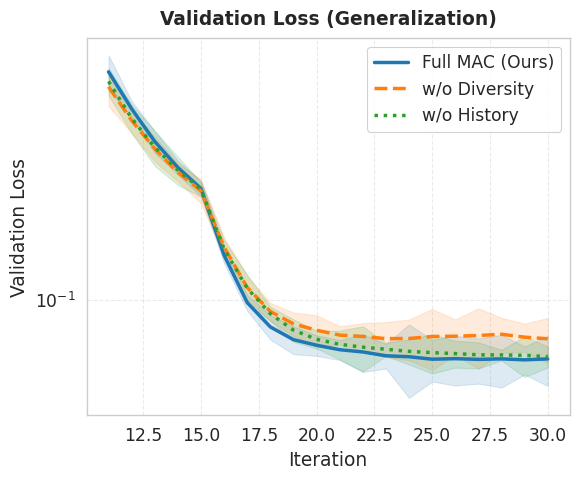

In [1]:
# === Jupyter 显示设置 ===
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================================
# 1️⃣  seed 聚合函数
# ==========================================================
def aggregate_over_seeds(df, metric, start_iter, end_iter=None):

    # 过滤迭代
    df = df[df["Iter"] >= start_iter].copy()

    if end_iter is not None:
        df = df[df["Iter"] <= end_iter]

    # 防止重复 Seed-Iter
    df = df.drop_duplicates(subset=["Seed", "Iter"])

    grouped = df.groupby("Iter")[metric]

    mean = grouped.mean()
    std = grouped.std()

    return mean, std


# ==========================================================
# 2️⃣  主绘图函数（单图版本）
# ==========================================================
def plot_ablation_comparison_aamas(
    full_ued_path,
    no_div_path,
    no_hist_path,
    start_iter=11,
    end_iter=None
):

    # === AAMAS Style ===
    sns.set_theme(context="paper", style="whitegrid", font_scale=1.4)
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.linestyle"] = "--"
    plt.rcParams["grid.alpha"] = 0.4

    paths = {
        "Full MAC (Ours)": (full_ued_path, "#1f77b4", "-"),
        "w/o Diversity": (no_div_path, "#ff7f0e", "--"),
        "w/o History": (no_hist_path, "#2ca02c", ":"),
    }

    fig, ax = plt.subplots(figsize=(6, 5))

    metric = "WM_Val_Loss"
    title = "Validation Loss (Generalization)"

    for label, (path, color, style) in paths.items():

        if not os.path.exists(path):
            print(f"[Warning] File not found: {path}")
            continue

        df = pd.read_csv(path)

        if metric not in df.columns:
            print(f"[Warning] {metric} not found in {label}")
            continue

        mean, std = aggregate_over_seeds(df, metric, start_iter, end_iter)

        # 平滑 mean（std 不平滑）
        mean_smooth = mean.rolling(window=5, min_periods=1).mean()

        x = mean.index

        ax.plot(
            x,
            mean_smooth,
            label=label,
            color=color,
            linestyle=style,
            linewidth=2.5,
        )

        ax.fill_between(
            x,
            mean_smooth - std,
            mean_smooth + std,
            color=color,
            alpha=0.15,
        )

    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Validation Loss")
    ax.set_yscale("log")

    ax.legend(loc="best", frameon=True, framealpha=0.9)

    plt.tight_layout()
    plt.savefig("ablation_study_aamas.png", dpi=300, bbox_inches="tight")
    plt.show()


# ==========================================================
# 3️⃣  使用你原来的路径
# ==========================================================

if __name__ == "__main__":

    f_full = "logs/results/experiment_summary_mask3_mse_weighted.csv"
    f_nodiv = "logs/results/experiment_summary_mask3_mse_no_diversity_weighted.csv"
    f_nohist = "logs/results/experiment_summary_mask3_mse_no_history_weighted.csv"

    plot_ablation_comparison_aamas(
        f_full,
        f_nodiv,
        f_nohist,
        start_iter=11,
        end_iter=30  # 👈 在这里控制显示到多少 iteration
    )

UED VS baseline VS DR


In [1]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================================
# 保持你原来的格式
# ==========================================================

sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (12, 10),
    "lines.linewidth": 2.5,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# ==========================================================
# 自动识别 seed 列
# ==========================================================

def get_seed_column(df):
    if "Seed" in df.columns:
        return "Seed"
    if "seed" in df.columns:
        return "seed"
    df["Seed"] = 0
    return "Seed"

# ==========================================================
# 插值 + seed mean/std
# ==========================================================

def compute_seed_mean_std_interpolated(df, loss_col, seed_col, grid_points=200):

    seeds = df[seed_col].unique()

    mins, maxs = [], []
    for s in seeds:
        d = df[df[seed_col] == s]
        mins.append(d["Transitions"].min())
        maxs.append(d["Transitions"].max())

    global_min = max(mins)
    global_max = min(maxs)

    grid = np.linspace(global_min, global_max, grid_points)

    all_curves = []

    for s in seeds:
        d = df[df[seed_col] == s]
        x = d["Transitions"].values
        y = d[loss_col].values
        interp_y = np.interp(grid, x, y)
        all_curves.append(interp_y)

    all_curves = np.array(all_curves)

    mean = np.mean(all_curves, axis=0)
    std = np.std(all_curves, axis=0)

    return grid, mean, std

# ==========================================================
# 主函数
# ==========================================================

def plot_three_methods_warmup_aligned(
    ued_path,
    dr_path,
    baseline_path,
    warmup_iter=10,
    max_k=150  # 横轴最大值（k transitions）
):

    max_transition = max_k * 1000

    methods = {
        "MAC": {
            "path": ued_path,
            "color": "#1f77b4",
            "style": "-"
        },
        "DR Baseline": {
            "path": dr_path,
            "color": "#d62728",
            "style": "--"
        },
        "Baseline": {
            "path": baseline_path,
            "color": "#2ca02c",
            "style": "-."
        }
    }

    fig, ax = plt.subplots(figsize=(8, 6))

    for label, config in methods.items():

        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p

        if not os.path.exists(p):
            print(f"[Warning] Missing: {p}")
            continue

        df = pd.read_csv(p)
        seed_col = get_seed_column(df)

        # =========================================
        # Baseline
        # =========================================
        if "transitions" in df.columns:

            loss_col = "avg_target_loss"
            df["Transitions"] = df["transitions"]

        # =========================================
        # UED / DR
        # =========================================
        else:

            loss_col = "WM_Val_Loss"
            df = df.sort_values([seed_col, "Iter"])

            if label == "MAC":
                # 只对 MAC 过滤 warmup
                df = df[df["Iter"] > warmup_iter].copy()

            df["Transitions"] = df.groupby(seed_col)["New_Data_Size"].cumsum()

        # =========================================
        # 限制最大 transition（统计也裁剪）
        # =========================================
        df = df[df["Transitions"] <= max_transition].copy()

        if len(df) == 0:
            continue

        # =========================================
        # 计算 mean/std
        # =========================================

        grid, mean, std = compute_seed_mean_std_interpolated(
            df,
            loss_col,
            seed_col
        )

        x = grid / 1000  # k transitions

        ax.plot(
            x,
            mean,
            label=label,
            color=config["color"],
            linestyle=config["style"],
            linewidth=2.5
        )

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            color=config["color"],
            alpha=0.15
        )

    ax.set_title("Generalization Performance Comparison", fontweight='bold')
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_ylabel("Target Task Loss (Log Scale)")
    ax.set_yscale("log")
    ax.set_xlim(0, max_k)  # 限制横轴显示
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend()

    save_path = "three_method_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_path}")

# ==========================================================
# main
# ==========================================================

if __name__ == "__main__":

    f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
    f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"
    f_baseline = "logs/results/target_loss_baseline_ued.csv"

    plot_three_methods_warmup_aligned(
        f_ued,
        f_dr,
        f_baseline,
        warmup_iter=10,
        max_k=150
    )


Saved to three_method_comparison.png


### visualization for Crafter

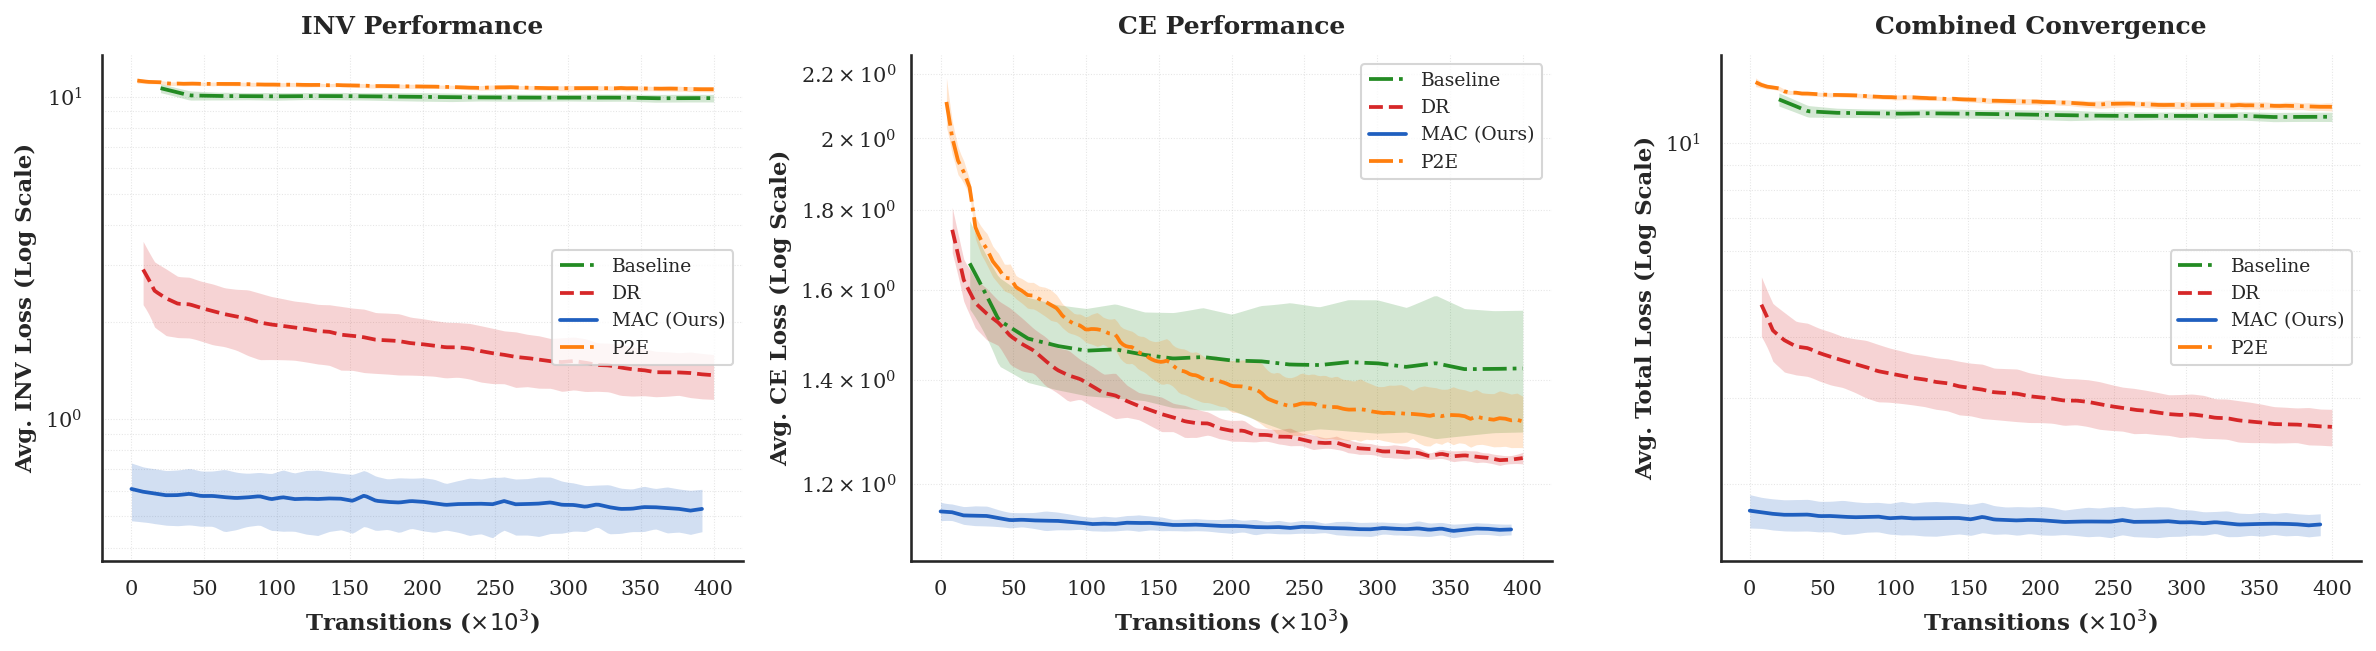

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob

%matplotlib inline
sns.set_theme(style="white", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.bbox": "tight"
})

csv_baseline_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/crafter_baseline_results.csv'
csv_dr_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/dr_summary_crafter.csv'
csv_dr_legacy_glob = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/dr_summary_crafter_*.csv'
csv_ued_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/crafter_ued_results.csv'
csv_p2e_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/p2e_baseline_crafter_n4000_m5_summary.csv'


def _load_dr_dataframe():
    if os.path.exists(csv_dr_path):
        return pd.read_csv(csv_dr_path)

    legacy_files = sorted(
        p for p in glob.glob(csv_dr_legacy_glob)
        if not p.endswith('dr_summary_crafter.csv')
    )
    if not legacy_files:
        raise FileNotFoundError('No DR CSV found.')

    frames = []
    for path in legacy_files:
        df = pd.read_csv(path)
        if 'Seed' not in df.columns:
            seed_from_name = os.path.splitext(os.path.basename(path))[0].split('_')[-1]
            try:
                df['Seed'] = int(seed_from_name)
            except ValueError:
                df['Seed'] = 0
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def _aggregate_seed_curves(
    df,
    y_cols,
    seed_col='Seed',
    iter_col='Iter',
    warmup_iter=0,
    step_col='New_Data_Size',
    cumulative_col=None,
    x_scale=1000,
    num_points=200,
    reset_from_first=False,   # 关键开关：是否把每个seed的x从0重置
):
    req = {seed_col, *y_cols}
    for c in [iter_col, step_col, cumulative_col]:
        if c is not None:
            req.add(c)
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise KeyError(f'Missing columns: {missing}')

    d = df.copy()
    for c in y_cols + ([step_col] if step_col else []) + ([cumulative_col] if cumulative_col else []) + ([iter_col] if iter_col else []):
        if c is not None and c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')

    seed_curves = []
    for _, g in d.groupby(seed_col):
        if iter_col in g.columns:
            g = g.sort_values(iter_col).copy()
        else:
            g = g.copy()

        if warmup_iter > 0 and iter_col in g.columns:
            g = g[g[iter_col] > warmup_iter].copy()
        if g.empty:
            continue

        if cumulative_col is not None and cumulative_col in g.columns:
            if reset_from_first:
                g['x_k'] = (g[cumulative_col] - g[cumulative_col].iloc[0]) / x_scale
            else:
                g['x_k'] = g[cumulative_col] / x_scale
        else:
            csum = g[step_col].fillna(0).cumsum()
            if reset_from_first:
                g['x_k'] = (csum - csum.iloc[0]) / x_scale
            else:
                g['x_k'] = csum / x_scale

        g = g[['x_k'] + y_cols].dropna(subset=['x_k']).groupby('x_k', as_index=False)[y_cols].mean()
        if len(g) < 2:
            continue
        seed_curves.append(g)

    if not seed_curves:
        raise ValueError('No valid seed curves to aggregate.')

    xmin = max(c['x_k'].min() for c in seed_curves)
    xmax = min(c['x_k'].max() for c in seed_curves)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax <= xmin:
        raise ValueError('Invalid x range for seed aggregation.')

    x_grid = np.linspace(xmin, xmax, num_points)
    out = {'x_k': x_grid}

    for col in y_cols:
        ys = []
        for c in seed_curves:
            x = c['x_k'].to_numpy(dtype=float)
            y = c[col].to_numpy(dtype=float)
            order = np.argsort(x)
            x, y = x[order], y[order]
            if len(np.unique(x)) < 2:
                continue
            ys.append(np.interp(x_grid, x, y))

        if not ys:
            continue
        ys = np.vstack(ys)
        out[col] = ys.mean(axis=0)
        out[col + '_std'] = ys.std(axis=0, ddof=1) if ys.shape[0] > 1 else np.zeros_like(x_grid)
        out[col + '_n'] = ys.shape[0]

    return pd.DataFrame(out)


def run_publication_visualization():
    needed = [csv_baseline_path, csv_ued_path, csv_p2e_path]
    if not all(os.path.exists(p) for p in needed):
        print("Error: 找不到部分 CSV 文件，请检查路径。")
        return

    metric_cols = ['target_val_val_inv_loss', 'target_val_val_ce_loss', 'target_val_avg_val_loss_wm']

    # Baseline: 不重置x，保持累计到400k
    df_base_raw = pd.read_csv(csv_baseline_path)
    df_base = _aggregate_seed_curves(
        df_base_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=0,
        step_col='data_size',
        cumulative_col='cumulative_data_size',
        x_scale=1000,
        reset_from_first=False,
    )

    # DR: 不重置x
    df_dr_raw = _load_dr_dataframe()
    df_dr = _aggregate_seed_curves(
        df_dr_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=0,
        step_col='New_Data_Size',
        cumulative_col=None,
        x_scale=1000,
        reset_from_first=False,
    )

    # UED: 去掉前10轮warmup + 从warmup后重置x
    df_ued_raw = pd.read_csv(csv_ued_path)
    df_ued = _aggregate_seed_curves(
        df_ued_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=10,
        step_col='New_Data_Size',
        cumulative_col=None,
        x_scale=1000,
        reset_from_first=True,
    )

    # P2E: 不重置x
    df_p2e_raw = pd.read_csv(csv_p2e_path)
    df_p2e = _aggregate_seed_curves(
        df_p2e_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=0,
        step_col='New_Data_Size',
        cumulative_col='Cumulative_Transitions',
        x_scale=1000,
        reset_from_first=False,
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    configs = [
        ('target_val_val_inv_loss', 'Avg. INV Loss', 'INV Performance'),
        ('target_val_val_ce_loss', 'Avg. CE Loss', 'CE Performance'),
        ('target_val_avg_val_loss_wm', 'Avg. Total Loss', 'Combined Convergence'),
    ]

    def n_of(df, col):
        key = col + '_n'
        return int(df[key].iloc[0]) if key in df.columns and len(df) else 0

    styles = {
        'Baseline': {'df': df_base, 'color': '#238B23', 'ls': '-.', 'label': f'Baseline'},
        'DR':       {'df': df_dr,   'color': '#D62728', 'ls': '--', 'label': f'DR'},
        'UED':      {'df': df_ued,  'color': '#1F5FBF', 'ls': '-',  'label': f'MAC (Ours)'},
        'P2E':      {'df': df_p2e,  'color': '#FF7F0E', 'ls': '-.', 'label': f'P2E'},
    }

    for i, (col, ylabel, title) in enumerate(configs):
        ax = axes[i]

        for name in ['Baseline', 'DR', 'UED', 'P2E']:
            s = styles[name]
            d = s['df']
            if col not in d.columns:
                continue

            ax.plot(d['x_k'], d[col], color=s['color'], ls=s['ls'], label=s['label'], linewidth=1.8)

            std_col = col + '_std'
            if std_col in d.columns:
                ax.fill_between(
                    d['x_k'],
                    d[col] - d[std_col],
                    d[col] + d[std_col],
                    color=s['color'],
                    alpha=0.20,
                    linewidth=0
                )

        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_ylabel(f"{ylabel} (Log Scale)", fontweight='bold')
        ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle=':', alpha=0.5, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='best', frameon=True, edgecolor='0.8')

    plt.tight_layout()
    plt.show()


run_publication_visualization()


### crafter continues learning vs baseline

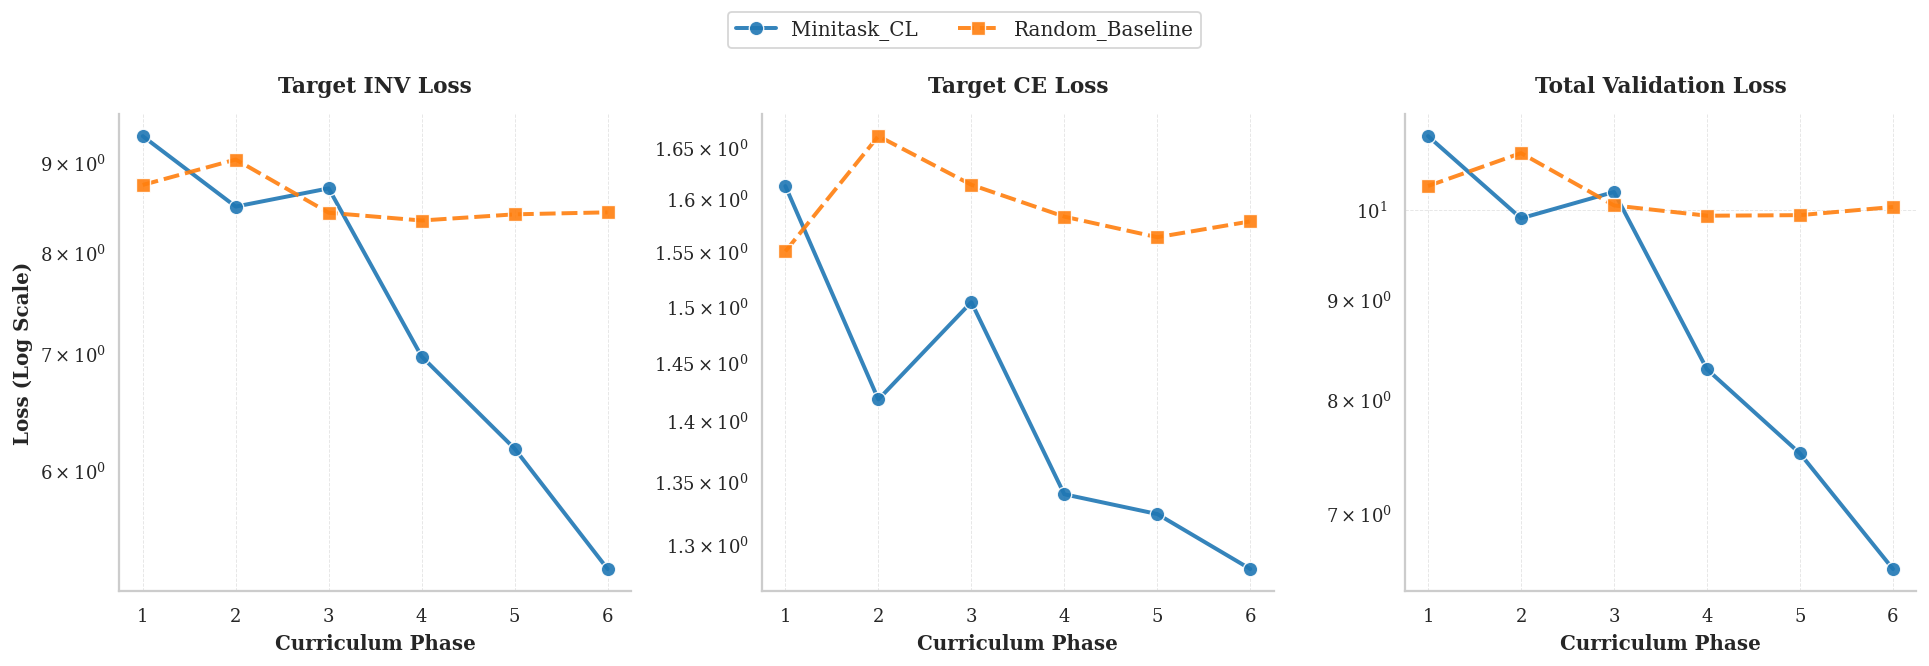

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 确保在 Jupyter 中内联显示
%matplotlib inline

# ----------------- NeurIPS Academic Figure Style -----------------
sns.set_theme(style="whitegrid", font="serif") 
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 130,
    "savefig.bbox": "tight"
})

# ----------------- 路径设置 -----------------
csv_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/cl_comparison_results.csv'

def plot_cl_comparison():
    # 1. 检查并读取 CSV
    if not os.path.exists(csv_path):
        print(f"Error: 找不到文件 {csv_path}")
        return
    
    df = pd.read_csv(csv_path)

    # 2. 绘图配置 (指标列名, 标题)
    metrics = [
        ('target_val_val_inv_loss', 'Target INV Loss'),
        ('target_val_val_ce_loss', 'Target CE Loss'),
        ('target_val_avg_val_loss_wm', 'Total Validation Loss')
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    
    # 颜色与标记 (Minitask 用沉稳蓝, Random 用学术橙)
    palette = {'Minitask_CL': '#1F77B4', 'Random_Baseline': '#FF7F0E'}
    markers = {'Minitask_CL': 'o', 'Random_Baseline': 's'}

    for i, (col, title) in enumerate(metrics):
        ax = axes[i]
        
        # 3. 绘制折线图
        sns.lineplot(data=df, x='phase', y=col, hue='experiment_type', 
                     style='experiment_type', markers=markers, palette=palette,
                     linewidth=2.2, markersize=8, ax=ax, alpha=0.9)
        
        # 4. 精细化美化
        ax.set_title(title, fontweight='bold', pad=12)
        ax.set_ylabel('Loss (Log Scale)' if i==0 else '', fontweight='bold')
        ax.set_xlabel('Curriculum Phase', fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        
        # 采用 Log Scale 观察
        ax.set_yscale('log')
        
        # 网格与边框处理
        ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # 移除默认图例，在全局统一添加
        ax.get_legend().remove()

    # 5. 全局图例整合
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=2, frameon=True, fontsize=11, edgecolor='0.8')

    plt.tight_layout()
    plt.show()

# 执行
plot_cl_comparison()


### Bipedal continue learning

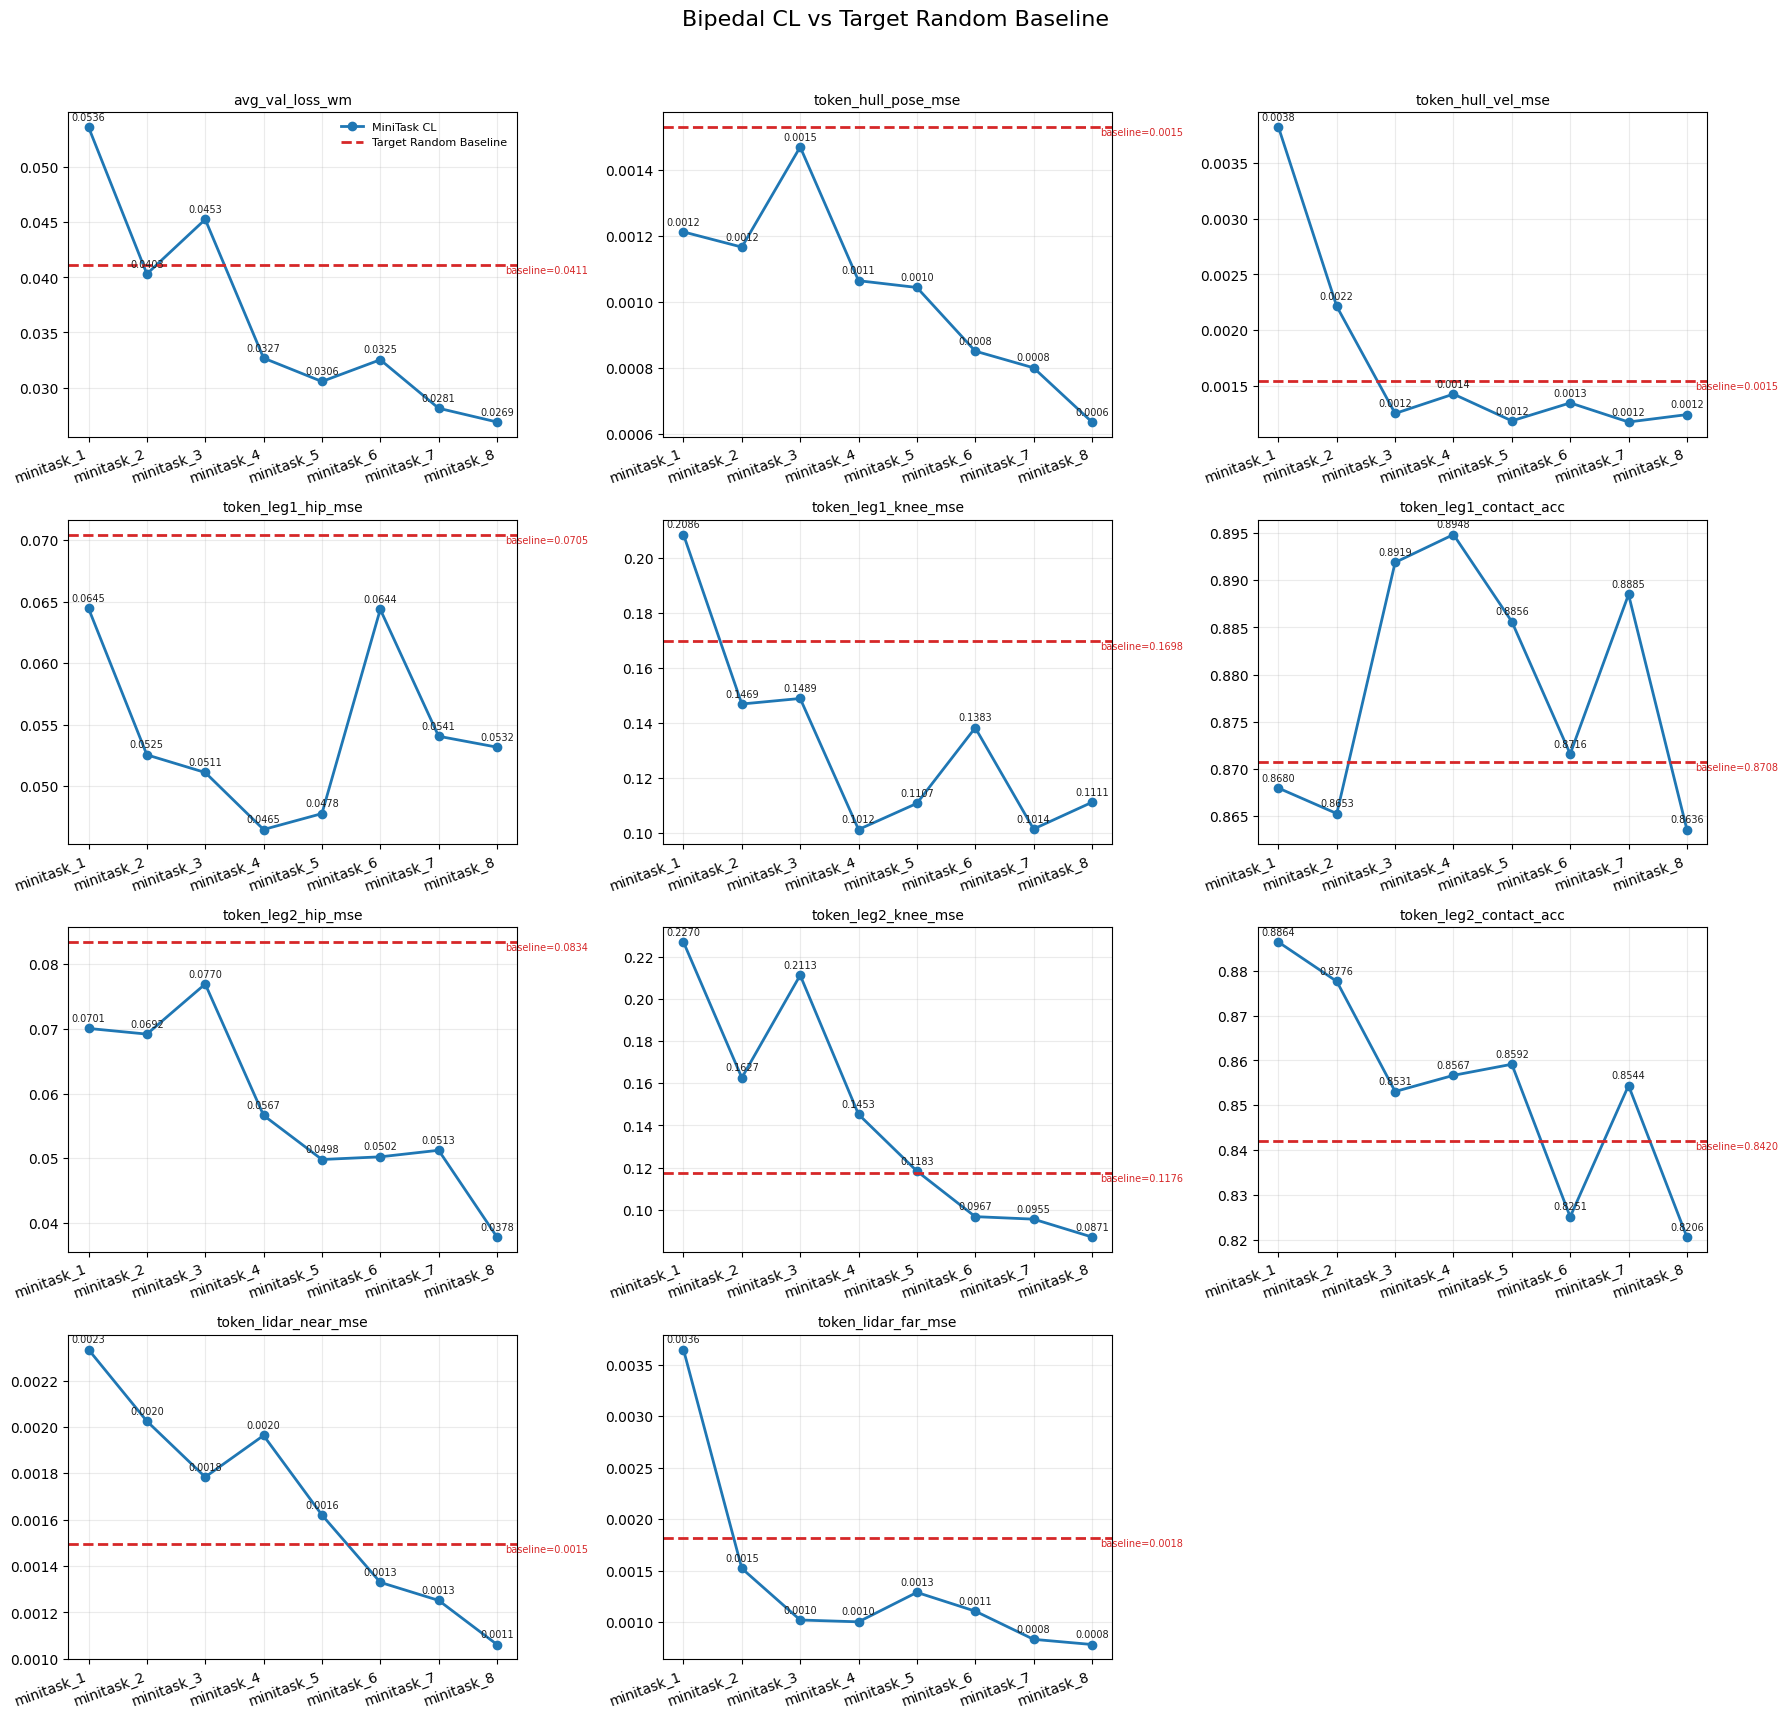

In [4]:
import math
import matplotlib.pyplot as plt
import pandas as pd

csv_path = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/cl_comparison_results.csv"

df = pd.read_csv(csv_path)
df = df[df["domain"] == "bipedalwalker"].copy()

mini_df = (
    df[df["experiment_type"] == "Bipedal_Minitask_CL"]
    .sort_values("phase")
    .reset_index(drop=True)
)

baseline_df = (
    df[df["experiment_type"] == "Bipedal_Target_Random_Baseline"]
    .sort_values("phase")
    .reset_index(drop=True)
)

if mini_df.empty:
    raise ValueError("没有找到 Bipedal_Minitask_CL 的数据")
if baseline_df.empty:
    raise ValueError("没有找到 Bipedal_Target_Random_Baseline 的数据")

baseline_row = baseline_df.iloc[0]

x = list(range(len(mini_df)))
x_labels = mini_df["task"].astype(str).tolist()

non_metric_cols = {"experiment_type", "domain", "phase", "task"}
exclude_metrics = {
    "train_best_val_loss",
    "target_val_token_leg1_contact_bce",
    "target_val_token_leg2_contact_bce",
}

metric_cols = [
    c for c in df.columns
    if c not in non_metric_cols and c not in exclude_metrics
]

if not metric_cols:
    raise ValueError("没有找到可绘制的指标列")

n_metrics = len(metric_cols)
ncols = 3
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
if n_metrics == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, metric in enumerate(metric_cols):
    ax = axes[i]
    y = mini_df[metric].astype(float).tolist()
    baseline_value = float(baseline_row[metric])

    ax.plot(x, y, marker="o", linewidth=2, color="#1f77b4", label="MiniTask CL")
    ax.axhline(
        baseline_value,
        linestyle="--",
        linewidth=2,
        color="#d62728",
        label="Target Random Baseline"
    )

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.4f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=7,
            color="#1f1f1f"
        )

    ax.annotate(
        f"baseline={baseline_value:.4f}",
        (x[-1], baseline_value),
        textcoords="offset points",
        xytext=(6, -6),
        ha="left",
        fontsize=7,
        color="#d62728"
    )

    ax.set_title(metric.replace("target_val_", ""), fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=20, ha="right")
    ax.grid(True, alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8, frameon=False, loc="best")

for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Bipedal CL vs Target Random Baseline", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


### Bipedal MAC vs all baselines

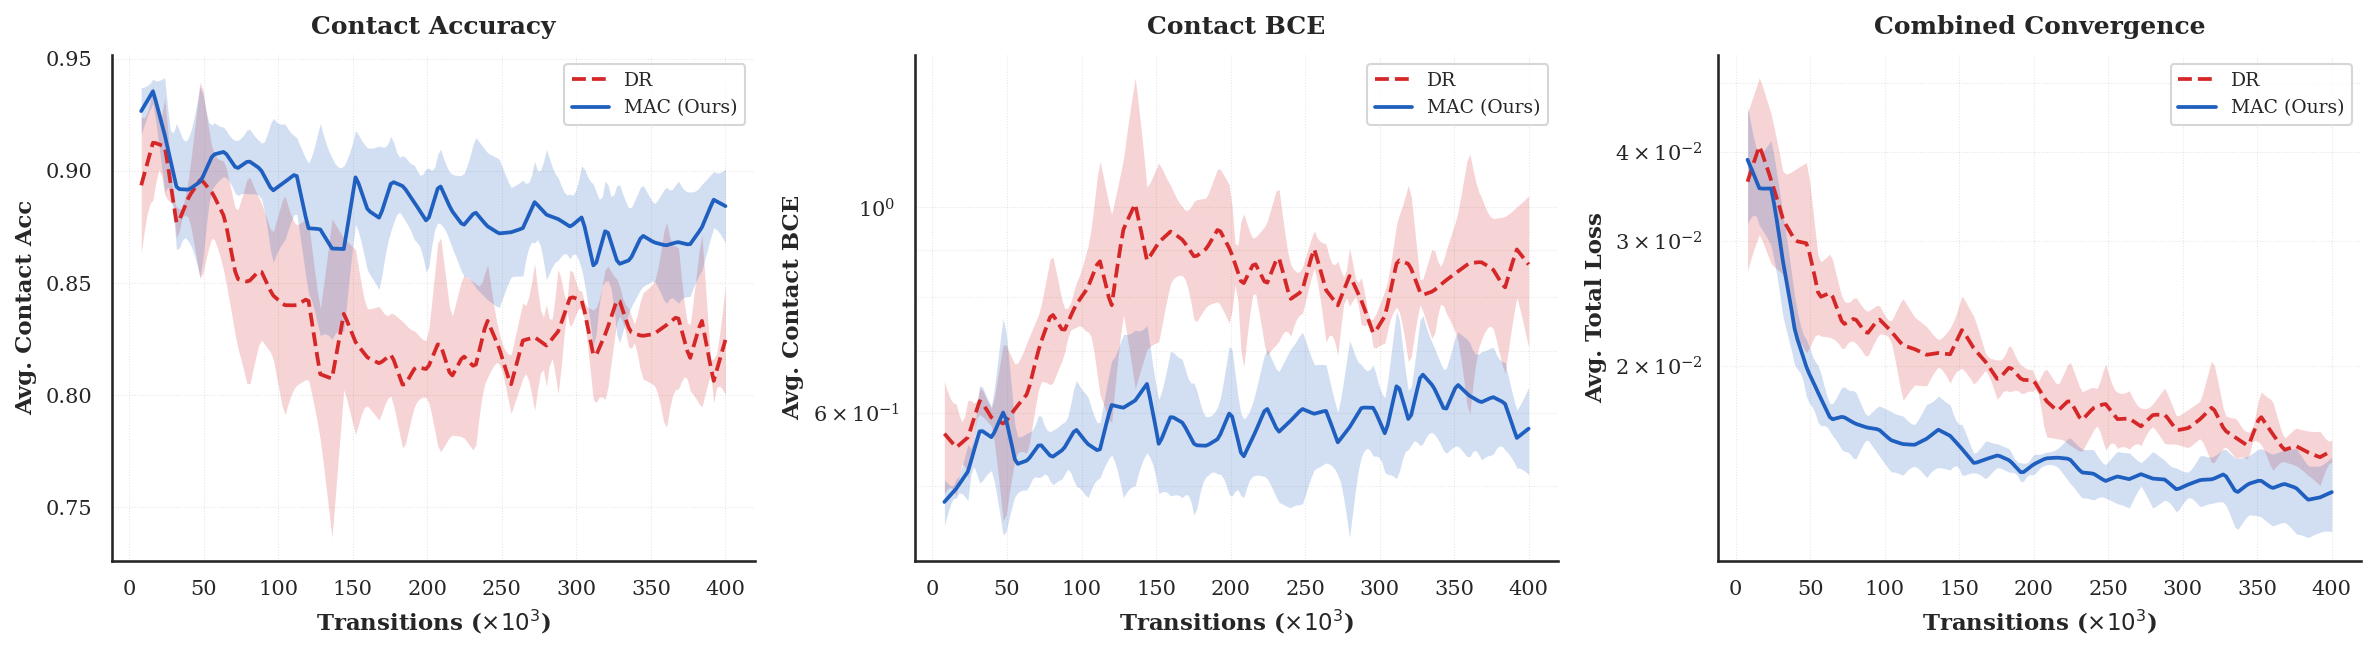

In [5]:
def run_bipedal_visualization():
    needed = [csv_ued_path]
    if not all(os.path.exists(p) for p in needed):
        print("Error: 找不到部分 CSV 文件，请检查路径。")
        return

    metric_cols = ['target_val_contact_acc', 'target_val_contact_bce', 'target_val_avg_val_loss_wm']

    # DR: 从头开始显示，不裁 warmup，保留原生相对坐标
    df_dr_raw = _load_dr_dataframe()
    df_dr_raw = df_dr_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_dr = _aggregate_seed_curves(
        df_dr_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=0,
        step_col='New_Data_Size',
        cumulative_col=None,
        x_scale=1000,
        reset_from_first=False,
    )

    # UED / MAC: 去掉前 10 轮 warmup
    df_ued_raw = pd.read_csv(csv_ued_path)
    df_ued_raw = df_ued_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_ued = _aggregate_seed_curves(
        df_ued_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=10,
        step_col='New_Data_Size',
        cumulative_col=None,
        x_scale=1000,
        reset_from_first=False,  # <===== 修改点在这里：改成 False，关闭首点归零！
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    configs = [
        ('target_val_contact_acc', 'Avg. Contact Acc', 'Contact Accuracy'),
        ('target_val_contact_bce', 'Avg. Contact BCE', 'Contact BCE'),
        ('target_val_avg_val_loss_wm', 'Avg. Total Loss', 'Combined Convergence'),
    ]

    styles = {
        'DR':  {'df': df_dr,  'color': '#D62728', 'ls': '--', 'label': 'DR'},
        'UED': {'df': df_ued, 'color': '#1F5FBF', 'ls': '-',  'label': 'MAC (Ours)'},
    }

    for i, (col, ylabel, title) in enumerate(configs):
        ax = axes[i]

        for name in ['DR', 'UED']:
            s = styles[name]
            d = s['df']
            if col not in d.columns:
                continue

            ax.plot(
                d['x_k'],
                d[col],
                color=s['color'],
                ls=s['ls'],
                label=s['label'],
                linewidth=1.8
            )

            std_col = col + '_std'
            if std_col in d.columns:
                ax.fill_between(
                    d['x_k'],
                    d[col] - d[std_col],
                    d[col] + d[std_col],
                    color=s['color'],
                    alpha=0.20,
                    linewidth=0
                )

        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold')

        if col in ['target_val_contact_bce', 'target_val_avg_val_loss_wm']:
            ax.set_yscale('log')

        ax.grid(True, which='both', linestyle=':', alpha=0.5, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='best', frameon=True, edgecolor='0.8')

    plt.tight_layout()
    plt.show()

run_bipedal_visualization()


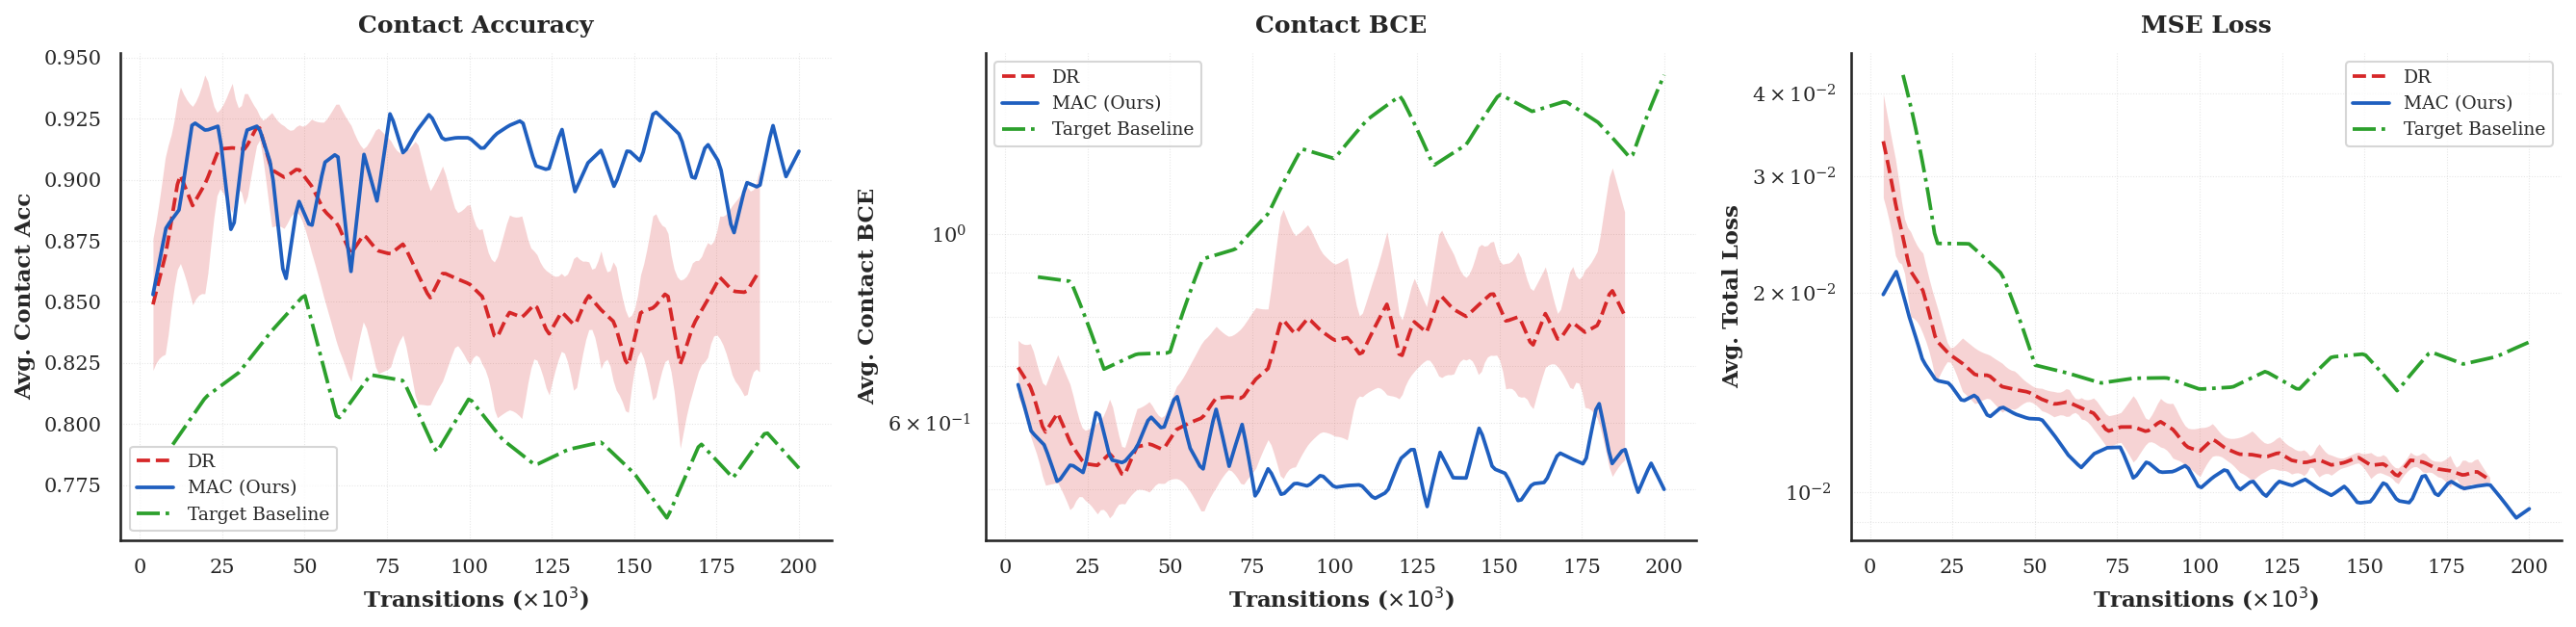

In [ ]:
# baseline 主文件 + 备选 mix
csv_baseline_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_target_baseline/target_baseline_bipedalwalker.csv'
csv_baseline_mix_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_target_baseline/target_baseline_bipedalwalker_mix.csv'

def run_bipedal_visualization():
    needed = [csv_ued_path]
    if not all(os.path.exists(p) for p in needed):
        print("Error: 找不到部分 CSV 文件，请检查路径。")
        return

    metric_cols = ['target_val_contact_acc', 'target_val_contact_bce', 'target_val_avg_val_loss_wm']

    # DR
    df_dr_raw = _load_dr_dataframe().drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_dr = _aggregate_seed_curves(
        df_dr_raw, y_cols=metric_cols, seed_col='Seed', iter_col='Iter', warmup_iter=0,
        step_col='New_Data_Size', x_scale=1000, reset_from_first=False
    )

    # MAC/UED
    df_ued_raw = pd.read_csv(csv_ued_path).drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_ued = _aggregate_seed_curves(
        df_ued_raw, y_cols=metric_cols, seed_col='Seed', iter_col='Iter', warmup_iter=10,
        step_col='New_Data_Size', x_scale=1000, reset_from_first=False
    )

    # Baseline
    baseline_file = csv_baseline_path if os.path.exists(csv_baseline_path) else csv_baseline_mix_path
    df_baseline = None
    if os.path.exists(baseline_file):
        df_base_raw = pd.read_csv(baseline_file)
        iter_col_base = 'Phase' if 'Phase' in df_base_raw.columns else 'Iter'
        dedup_cols = [c for c in ['Seed', iter_col_base] if c in df_base_raw.columns]
        if len(dedup_cols) >= 2:
            df_base_raw = df_base_raw.drop_duplicates(subset=dedup_cols, keep='last')

        df_baseline = _aggregate_seed_curves(
            df_base_raw, y_cols=metric_cols, seed_col='Seed', iter_col=iter_col_base, warmup_iter=0,
            step_col='data_size', cumulative_col='cumulative_data_size', x_scale=1000,
            reset_from_first=False
        )
    else:
        print("Warning: baseline file not found.")

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    configs = [
        ('target_val_contact_acc', 'Avg. Contact Acc', 'Contact Accuracy'),
        ('target_val_contact_bce', 'Avg. Contact BCE', 'Contact BCE'),
        ('target_val_avg_val_loss_wm', 'Avg. Total Loss', 'MSE Loss'),
    ]
    styles = {
        'DR':   {'df': df_dr,       'color': '#D62728', 'ls': '--', 'label': 'DR'},
        'UED':  {'df': df_ued,      'color': '#1F5FBF', 'ls': '-',  'label': 'MAC (Ours)'},
        'BASE': {'df': df_baseline, 'color': '#2CA02C', 'ls': '-.', 'label': 'Target Baseline'},  # 绿色
    }

    for i, (col, ylabel, title) in enumerate(configs):
        ax = axes[i]
        for name in ['DR', 'UED', 'BASE']:
            s = styles[name]
            d = s['df']
            if d is None or col not in d.columns:
                continue

            ax.plot(d['x_k'], d[col], color=s['color'], ls=s['ls'], label=s['label'], linewidth=1.8)
            std_col = col + '_std'
            if std_col in d.columns:
                ax.fill_between(d['x_k'], d[col]-d[std_col], d[col]+d[std_col],
                                color=s['color'], alpha=0.20, lw=0)

        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold')
        if col in ['target_val_contact_bce', 'target_val_avg_val_loss_wm']:
            ax.set_yscale('log')
        ax.grid(True, which='both', linestyle=':', alpha=0.5, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='best', frameon=True, edgecolor='0.8')

    plt.tight_layout()
    plt.show()

# 只执行上面这一个
run_bipedal_visualization()
